### Etap 3

Ostatnia część projektu związana jest z opracowaniem modelu regresji (2,5 pkt.), poprzez
zastosowanie poznanych na wykładzie i ćwiczeniach laboratoryjnych metodach doboru cech
(2,5 pkt.) i regularyzacji (2,5 pkt.) oraz opracowanie raportu opisującego przeprowadzone prace,
jak i wyciągnięte wnioski z otrzymanych wyników/zależności (2,5 pkt.).

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie zbioru danych

In [3]:
df = pd.read_csv('data/df_merged_without_outliers.csv')

Lista atrybutów o rozkładzie prawo skośnym:

In [4]:
right_skewed = np.array(['TotalPop', 'Hispanic', 'Black', 'Native', 'Asian', 'Pacific', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Average_House_Price'], dtype=object)

Lista atrybutów o rozkładzie lewo skośnym:

In [5]:
left_skewed = np.array(['White', 'Drive', 'PrivateWork'], dtype=object)

<Figure size 1000x2500 with 0 Axes>

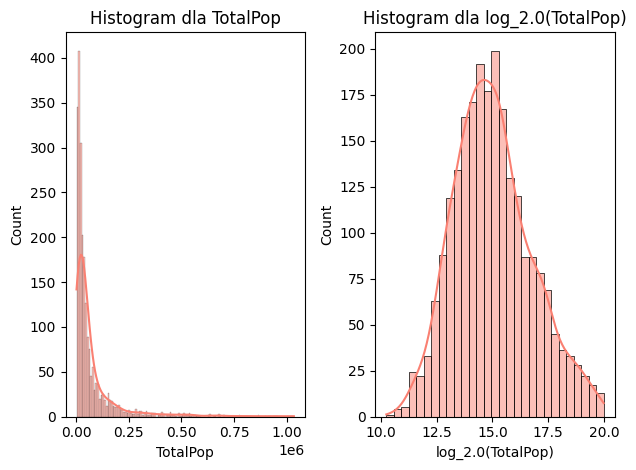

<Figure size 1000x2500 with 0 Axes>

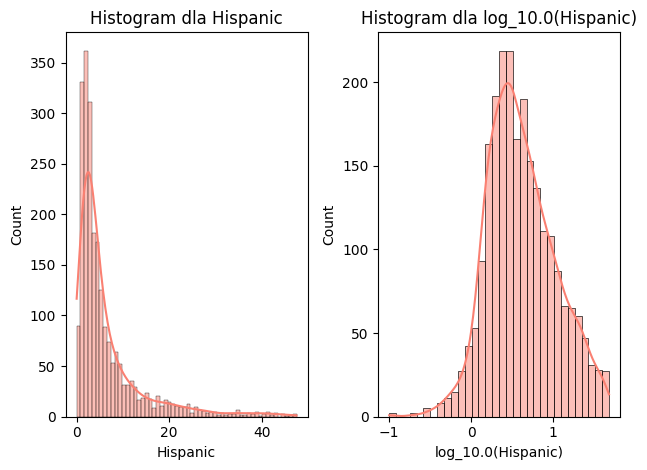

<Figure size 1000x2500 with 0 Axes>

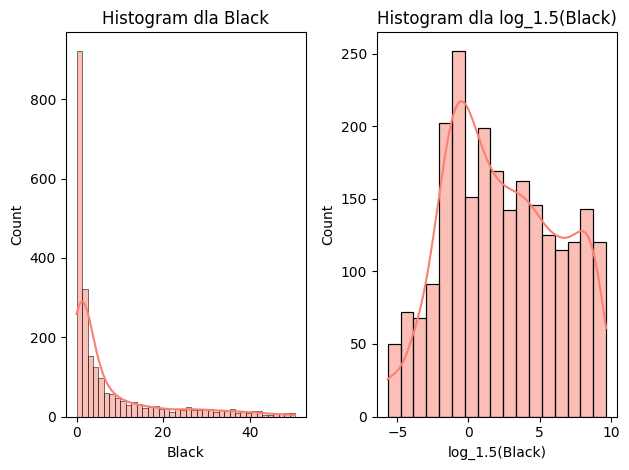

<Figure size 1000x2500 with 0 Axes>

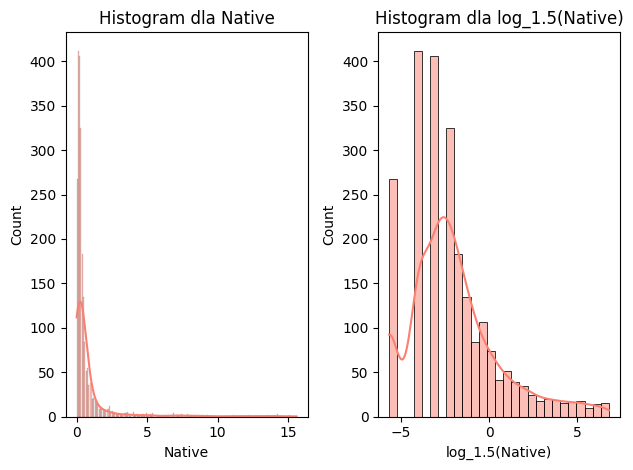

<Figure size 1000x2500 with 0 Axes>

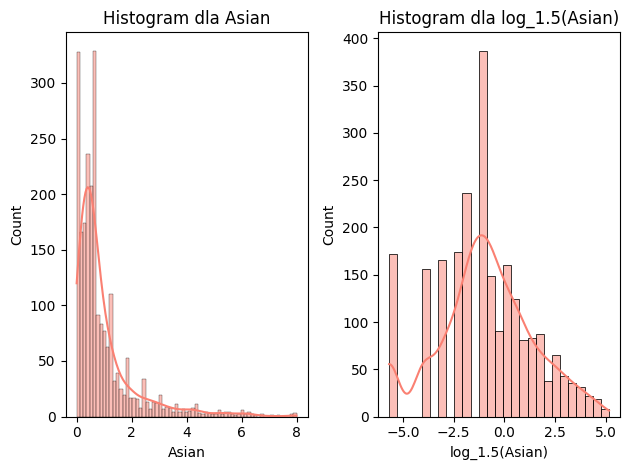

<Figure size 1000x2500 with 0 Axes>

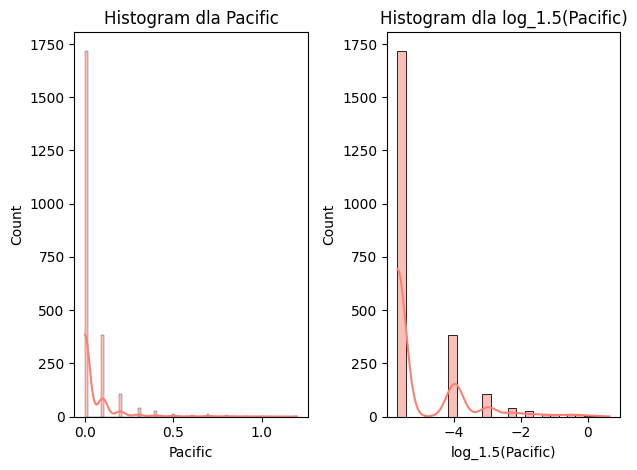

<Figure size 1000x2500 with 0 Axes>

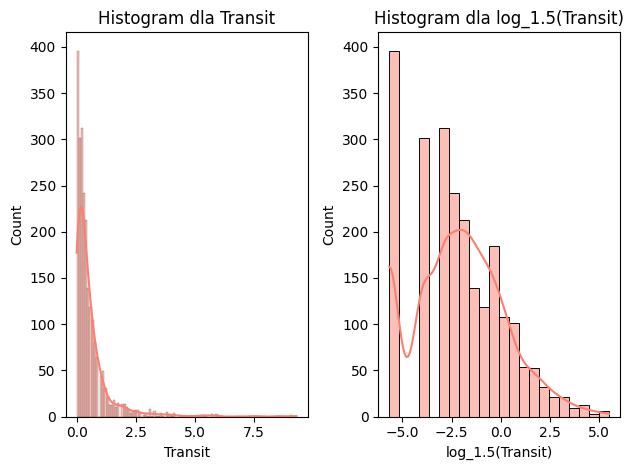

<Figure size 1000x2500 with 0 Axes>

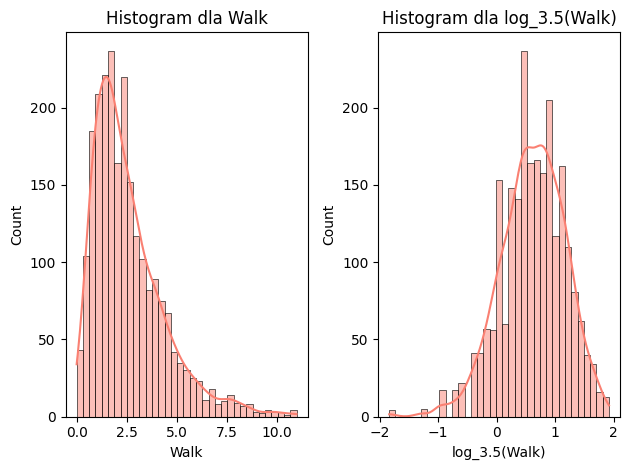

<Figure size 1000x2500 with 0 Axes>

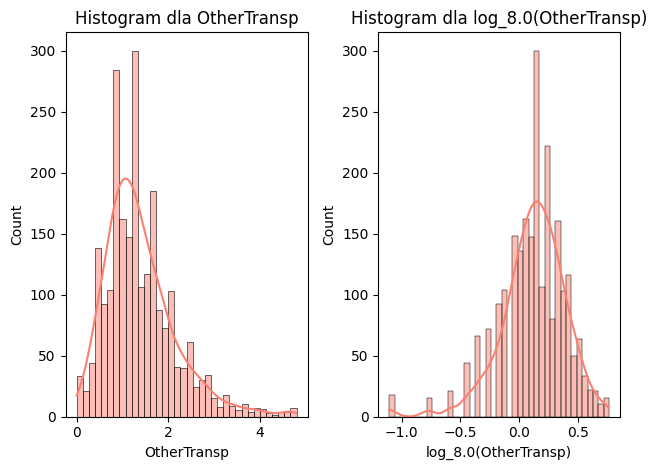

<Figure size 1000x2500 with 0 Axes>

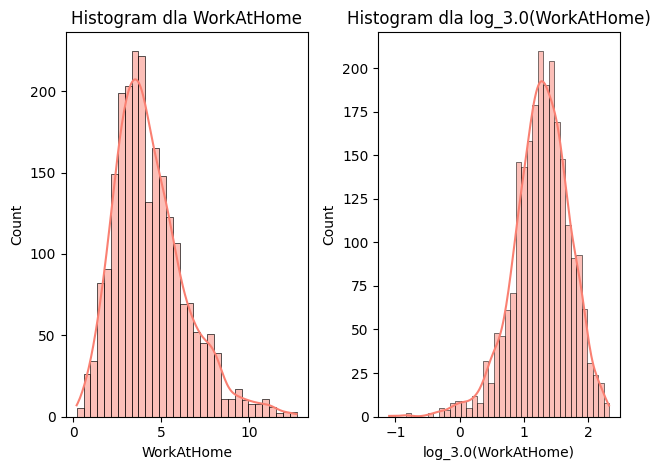

<Figure size 1000x2500 with 0 Axes>

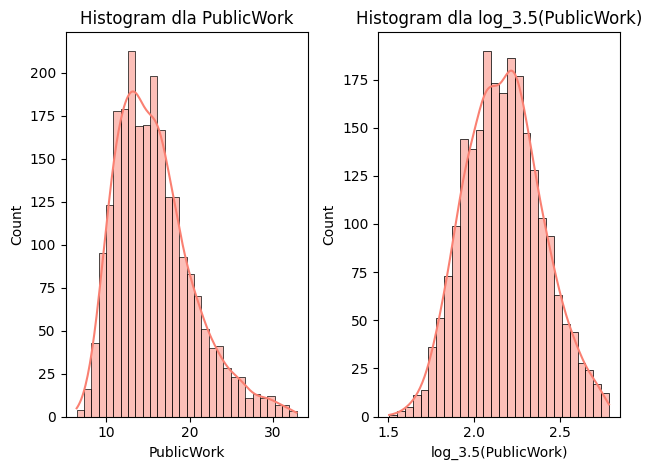

<Figure size 1000x2500 with 0 Axes>

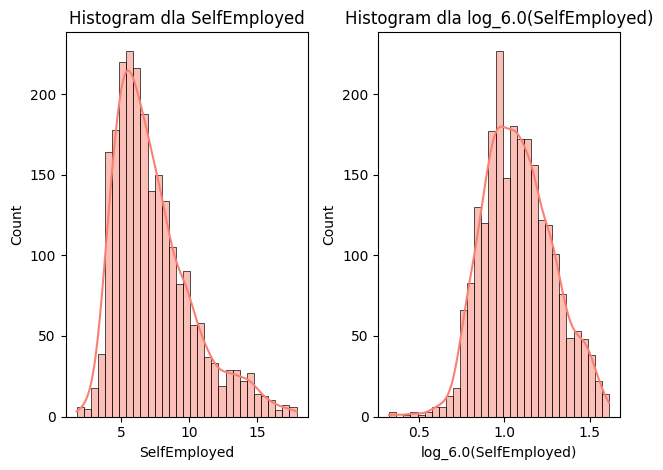

<Figure size 1000x2500 with 0 Axes>

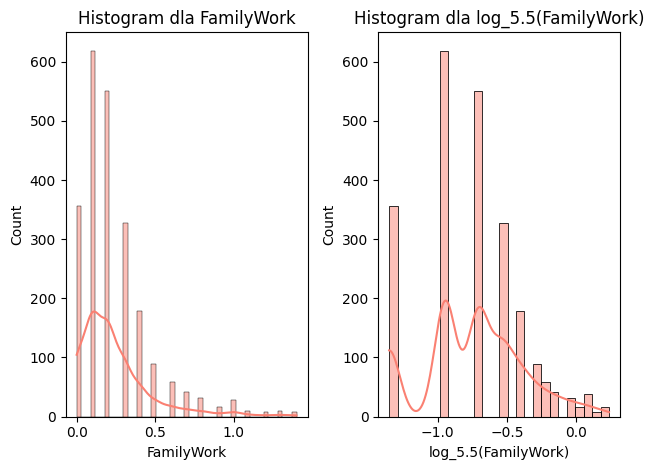

<Figure size 1000x2500 with 0 Axes>

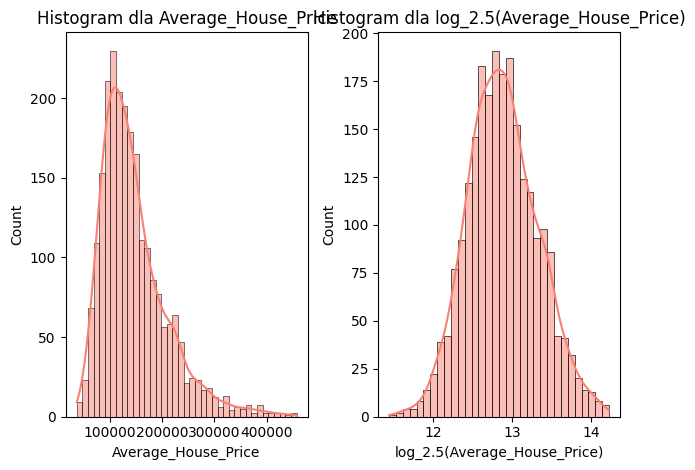

In [6]:
from scripts.right_skewed_to_normal import to_normal

for attr in right_skewed:
    df = to_normal(df, attr)

<Figure size 1000x2500 with 0 Axes>

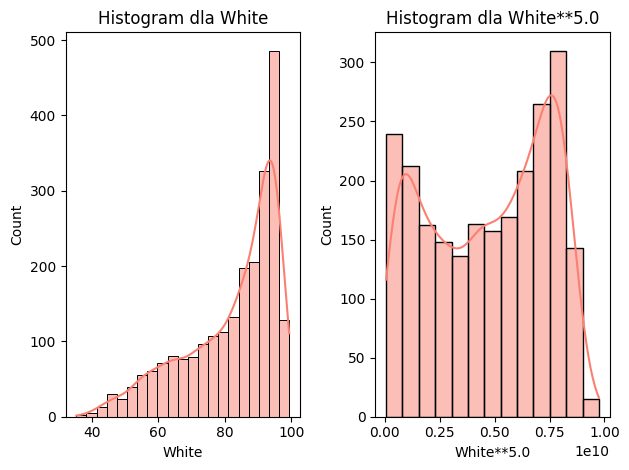

<Figure size 1000x2500 with 0 Axes>

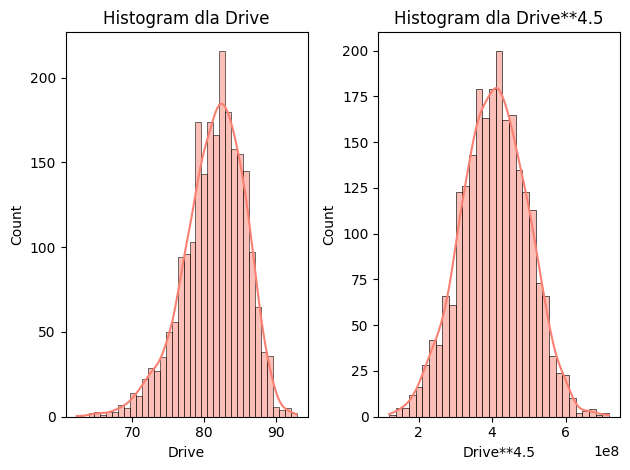

<Figure size 1000x2500 with 0 Axes>

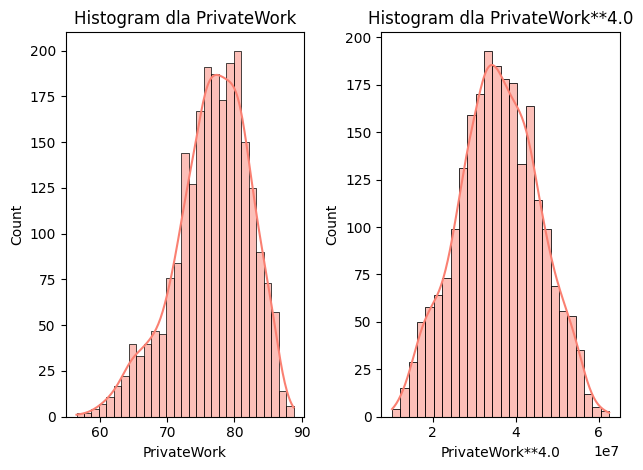

In [7]:
from scripts.left_skewed_to_normal import to_normal

for attr in left_skewed:
    df = to_normal(df, attr)

In [8]:
df

,Unnamed: 0,State,County,TotalPop,Hispanic,White,Black,Native,Asian,Pacific,...,logWalk,logOtherTransp,logWorkAtHome,logPublicWork,logSelfEmployed,logFamilyWork,logAverage_House_Price,exp_White,exp_Drive,exp_PrivateWork
0,0,Alabama,Autauga County,55036,2.7,75.4,18.9,0.3,0.9,0.0,...,-0.284711,0.161809,0.869744,2.403185,0.971373,-0.944091,13.116266,2.453210e+09,5.099342e+08,3.031207e+07
1,1,Alabama,Baldwin County,203360,4.4,83.1,9.5,0.8,0.7,0.0,...,-0.084103,0.087678,1.584241,2.047434,1.036020,-0.944091,13.427706,3.986728e+09,4.761912e+08,4.262314e+07
2,2,Alabama,Barbour County,26201,4.2,45.7,47.8,0.2,0.6,0.0,...,0.664858,0.282666,0.306270,2.358715,1.053194,-0.537493,12.594089,2.015243e+08,4.442108e+08,3.031207e+07
3,3,Alabama,Bibb County,22580,2.4,74.6,22.0,0.4,0.0,0.0,...,-0.731416,0.282666,0.427816,2.284711,1.036020,-0.537493,12.901011,2.325964e+09,5.206819e+08,3.353811e+07
4,4,Alabama,Blount County,57667,9.0,87.4,1.5,0.3,0.1,0.0,...,-0.553295,-0.333333,0.717685,1.983541,0.787487,-0.944091,13.006035,5.129089e+09,5.316049e+08,4.978714e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2322,2887,Wyoming,Sheridan County,29964,4.2,91.6,0.9,1.0,0.7,0.0,...,0.976861,-0.107309,1.584241,2.474604,1.036020,-0.706247,13.615051,6.484055e+09,3.561657e+08,2.598920e+07
2323,2889,Wyoming,Sweetwater County,44527,16.0,79.6,0.8,0.6,0.6,0.5,...,0.849890,0.161809,0.427816,2.302751,0.759575,-1.350689,13.402725,3.215819e+09,3.194315e+08,3.797333e+07
2324,2891,Wyoming,Uinta County,20758,9.1,87.7,0.1,0.9,0.1,0.0,...,0.145536,0.161809,0.675340,2.452733,1.061586,-0.406598,13.245697,5.217622e+09,3.175833e+08,2.628162e+07
2325,2892,Wyoming,Washakie County,8253,14.2,82.2,0.3,0.4,0.1,0.0,...,1.553295,0.161809,1.369070,2.471000,1.174340,-0.706247,13.125555,3.775715e+09,3.139119e+08,2.387309e+07


In [9]:
df.columns.to_list()

['Unnamed: 0',
 'State',
 'County',
 'TotalPop',
 'Hispanic',
 'White',
 'Black',
 'Native',
 'Asian',
 'Pacific',
 'IncomePerCap',
 'Poverty',
 'Professional',
 'Service',
 'Office',
 'Construction',
 'Production',
 'Drive',
 'Carpool',
 'Transit',
 'Walk',
 'OtherTransp',
 'WorkAtHome',
 'MeanCommute',
 'PrivateWork',
 'PublicWork',
 'SelfEmployed',
 'FamilyWork',
 'Unemployment',
 'Average_House_Price',
 'logTotalPop',
 'logHispanic',
 'logBlack',
 'logNative',
 'logAsian',
 'logPacific',
 'logTransit',
 'logWalk',
 'logOtherTransp',
 'logWorkAtHome',
 'logPublicWork',
 'logSelfEmployed',
 'logFamilyWork',
 'logAverage_House_Price',
 'exp_White',
 'exp_Drive',
 'exp_PrivateWork']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [13]:
y = df['IncomePerCap']
x = df.drop(columns=['IncomePerCap', 'Unnamed: 0', 'County', 'State'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
features = x_train.columns.values
features

array(['TotalPop', 'Hispanic', 'White', 'Black', 'Native', 'Asian',
       'Pacific', 'Poverty', 'Professional', 'Service', 'Office',
       'Construction', 'Production', 'Drive', 'Carpool', 'Transit',
       'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'PrivateWork',
       'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment',
       'Average_House_Price', 'logTotalPop', 'logHispanic', 'logBlack',
       'logNative', 'logAsian', 'logPacific', 'logTransit', 'logWalk',
       'logOtherTransp', 'logWorkAtHome', 'logPublicWork',
       'logSelfEmployed', 'logFamilyWork', 'logAverage_House_Price',
       'exp_White', 'exp_Drive', 'exp_PrivateWork'], dtype=object)

In [14]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [19]:
regresor = LinearRegression()
regresor.fit(x_train, y_train)
y_pred_train = regresor.predict(x_train)
y_pred_test = regresor.predict(x_test)
print('Multiple Linear Regression')
e_train= mean_squared_error(y_train, y_pred_train)
e_test = mean_squared_error(y_test, y_pred_test)
print('Mean Squared Error for train:', e_train)
print('Mean Squared Error for test:', e_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print('R2 Score for train:', r2_train)
print('R2 Score for test:', r2_test)



Multiple Linear Regression
Mean Squared Error for train: 4000591.6227247985
Mean Squared Error for test: 4098754.990464053
R2 Score for train: 0.8282110370541667
R2 Score for test: 0.8282427798556069


C:\Users\justy\AppData\Local\Temp\ipykernel_20800\3185005997.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")


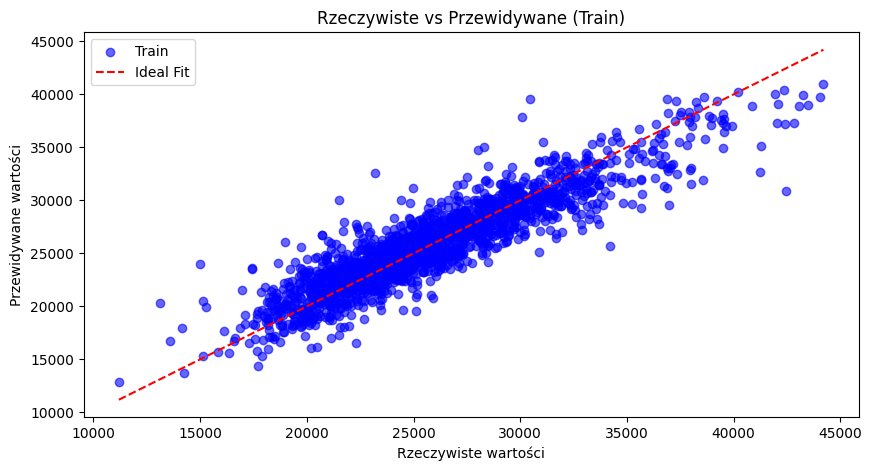

C:\Users\justy\AppData\Local\Temp\ipykernel_20800\3185005997.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


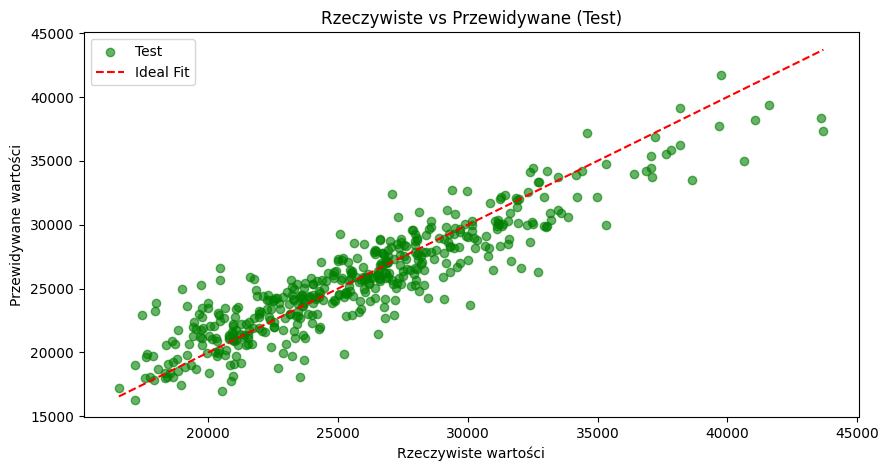

In [20]:
# Dla zbioru treningowego
plt.figure(figsize=(10, 5))
plt.scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs Przewidywane (Train)")
plt.legend()
plt.show()

# Dla zbioru testowego
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs Przewidywane (Test)")
plt.legend()
plt.show()

In [22]:

intercept = regresor.intercept_
print("Wyraz wolny (Intercept):", intercept)

coefficients = regresor.coef_
for idx, coef in enumerate(coefficients):
    print(f"{idx} współczynnik: {coef}")


Wyraz wolny (Intercept): 25913.00537345513
0 współczynnik: 216.17165036069903
1 współczynnik: -24.773029024469565
2 współczynnik: -59.79660496557899
3 współczynnik: 142.33340904815856
4 współczynnik: 310.1136340935121
5 współczynnik: 274.8722976725556
6 współczynnik: 201.58396368699894
7 współczynnik: -2140.1795019022948
8 współczynnik: -4216.666345725445
9 współczynnik: -2984.4569611602524
10 współczynnik: -2662.0083139795292
11 współczynnik: -3355.3326538937804
12 współczynnik: -5717.76816307073
13 współczynnik: 6155.61547986028
14 współczynnik: 1971.0134089354951
15 współczynnik: 1120.9973770841198
16 współczynnik: 1677.8042979562288
17 współczynnik: 586.5637044385174
18 współczynnik: 2053.0358716541314
19 współczynnik: -206.48415205342468
20 współczynnik: 893.3102469683871
21 współczynnik: -138.01675824506808
22 współczynnik: 707.9352437623642
23 współczynnik: -307.7488938711314
24 współczynnik: -190.12744992055855
25 współczynnik: 2314.7541987649665
26 współczynnik: -307.096443294

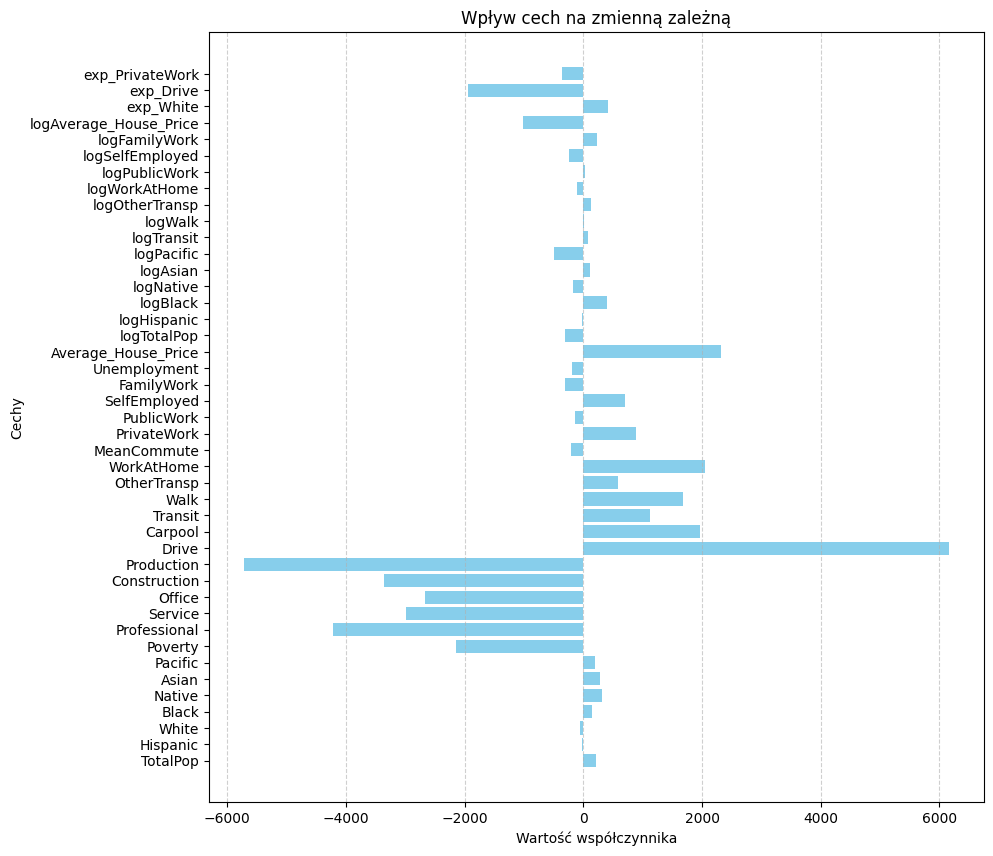

In [24]:
feature_names = x.columns 
coefficients = regresor.coef_


plt.figure(figsize=(10, 10))
plt.barh(feature_names, coefficients, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
poly_regresor = PolynomialFeatures(degree=4)
x_poly = poly_regresor.fit_transform(x_train)

moznaby dla roznych stopni wielomianu, ale idk czy jest sens sie nad tym tak rozwodzic czy lepiej skupic sie na innych modelach